In [1]:
from sklearn.metrics import mean_squared_error
import random
import numpy as np
import pandas as pd


# Load and pre-process data

In [2]:
target_col = "log_average_ms"

node_cols = ["Abs", "Acos", "Add", "ai.onnx.ml::CategoryMapper", "And", "ArgMax", 
             "AveragePool", "BatchNormalization", "Cast", "Ceil", "Clip", 
             "com.microsoft::BiasGelu", "com.microsoft::DynamicQuantizeLSTM", 
             "com.microsoft::DynamicQuantizeMatMul", "com.microsoft::FastGelu", 
             "com.microsoft::FusedConv", "com.microsoft::FusedGemm", 
             "com.microsoft::FusedMatMul", "com.microsoft::MatMulIntegerToFloat", 
             "com.microsoft::QGemm", "com.microsoft::QLinearAdd", 
             "com.microsoft::QLinearAveragePool", "com.microsoft::QLinearConcat", 
             "com.microsoft::QLinearGlobalAveragePool", "com.microsoft::QLinearLeakyRelu", 
             "com.microsoft::QLinearMul", "com.microsoft::QLinearSigmoid", 
             "com.microsoft::QuickGelu", "com.microsoft::SkipLayerNormalization", 
             "Compress", "Concat", "Constant", "ConstantOfShape", "Conv", "ConvInteger", 
             "ConvTranspose", "Cos", "CumSum", "DequantizeLinear", "Div", "Dropout", 
             "DynamicQuantizeLinear", "Einsum", "Equal", "Erf", "Exp", "Expand", 
             "EyeLike", "Flatten", "Floor", "Gather", "GatherElements", "GatherND", 
             "Gelu", "Gemm", "GlobalAveragePool", "Greater", "GreaterOrEqual", "Hardmax", 
             "HardSigmoid", "HardSwish", "Identity", "If", "InstanceNormalization", 
             "LayerNormalization", "LeakyRelu", "Less", "LessOrEqual", "local::preprocess", 
             "Log", "LogSoftmax", "Loop", "LRN", "LSTM", "MatMul", "MatMulInteger", 
             "Max", "MaxPool", "Min", "Mod", "Mul", "Neg", "NonMaxSuppression", "NonZero", 
             "Not", "OneHot", "Or", "Pad", "Pow", "PRelu", "QLinearConv", "QLinearMatMul", 
             "QuantizeLinear", "Range", "Reciprocal", "ReduceMax", "ReduceMean", "ReduceMin", 
             "ReduceProd", "ReduceSum", "Relu", "Reshape", "Resize", "RoiAlign", "Round", 
             "Scan", "ScatterElements", "ScatterND", "Shape", "Sigmoid", 
             "SimplifiedLayerNormalization", "Sin", "Slice", "Softmax", "Split", "Sqrt", 
             "Squeeze", "Sub", "Sum", "Tanh", "Tile", "TopK", "Transpose", "Trilu", 
             "Unsqueeze", "Where", "Xor"]

base_model_feature_cols = node_cols + ["conv_flops", "matmul_flops",
                "elementwise_mb", "reduction_mb", "normalization_mb",
                "movement_mb", "memory_mb"]

engineered_model_feature_cols = [
    "total_flops",
    "total_mb",
    "operational_intensity",
    "conv_frac",
    "matmul_frac",
    "elementwise_frac",
    "reduction_frac",
    "normalization_frac",
    "movement_frac",
    "memory_frac",
]

model_feature_cols = base_model_feature_cols + engineered_model_feature_cols

hardware_feature_cols = ["l1d_cache_kb", "l1i_cache_kb", "l2_cache_kb", 
                         "base_clock_mhz", "num_cores", "memory_bandwith_gbs", 
                         "cpu_provider", "bandwidth_per_core_gbs",
                         "l2_cache_per_core_kb", "clock_x_cores_mhz"]

metadata_cols = ["model", "cpu_provider",
                 "machine_type", "platform", "run_id"]

In [3]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# load test, train, val sets

train_df = pd.read_csv("/content/drive/MyDrive/Data/train_set.csv")
val_df = pd.read_csv("/content/drive/MyDrive/Data/val_set.csv")
test_df = pd.read_csv("/content/drive/MyDrive/Data/test_set.csv")

print("train:", train_df.shape)
print("val:", val_df.shape)
print("test:", test_df.shape)

train: (100252, 154)
val: (21483, 154)
test: (21483, 154)


In [5]:
assert list(train_df.columns) == list(val_df.columns) == list(test_df.columns)

train_df.head()

,model,input_dimensions,input_dtypes,output_dimensions,output_dtypes,conv_flops,matmul_flops,elementwise_mb,reduction_mb,normalization_mb,...,base_clock_mhz,memory_bandwith_gbs,cpu_provider,machine_type,platform,repo_file,average_ms,stddev_ms,min_ms,max_ms
0,hardcorenas_d_Opset17_extended.onnx,x:1x3x224x224,x:float32,668:1x1000,668:float32,472440512,2560000,50.528229,5.204269,0.000000,...,2300.000,717,intel,xeon_plat,bluehive,hardcorenas_d_Opset17.onnx,14.069188,0.082284,13.931521,14.247209
1,vit_base_patch8_224_in21k_Opset17_disable_all....,x:1x3x224x224,x:float32,1089:1x21843,1089:float32,231211008,156097479168,1771.169711,0.000000,792.141724,...,2450.000,205,amd,epyc,gcloud,vit_base_patch8_224_in21k_Opset17.onnx,1481.456045,150.199862,1094.324125,1632.506909
2,tf_efficientnetv2_m_in21ft1k_Opset17_basic.onnx,x:1x3x384x384,x:float32,2466:1x1000,2466:float32,31470991360,2560000,1201.339462,67.736023,0.000000,...,2449.998,205,amd,epyc,gcloud,tf_efficientnetv2_m_in21ft1k_Opset17.onnx,301.127424,12.889699,286.464729,324.336829
3,shufflenet_v2_x1_5_Opset16.onnx,x:1x3x224x224,x:float32,1137:1x1000,1137:float32,266034528,2048000,8.246674,1.630875,0.000000,...,2449.998,205,amd,epyc,gcloud,shufflenet_v2_x1_5_Opset16.onnx,8.161246,0.036559,8.080030,8.197800
4,wide_resnet101_2_Opset16_timm.onnx,x:1x3x224x224,x:float32,971:1x1000,971:float32,45502005248,4096000,252.656250,4.218750,0.000000,...,2300.000,717,intel,xeon_plat,bluehive,wide_resnet101_2_Opset16_timm.onnx,38.147223,0.068437,38.035275,38.292409


In [6]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler

SEED = 67
random.seed(SEED)
np.random.seed(SEED)

In [7]:
# pre-processing function

def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
  df = df.copy()

  total_flops = df["conv_flops"].fillna(0) + df["matmul_flops"].fillna(0)
  total_mb = (
      df["elementwise_mb"].fillna(0)
      + df["reduction_mb"].fillna(0)
      + df["normalization_mb"].fillna(0)
      + df["movement_mb"].fillna(0)
      + df["memory_mb"].fillna(0)
  )

  df["total_flops"] = total_flops
  df["total_mb"] = total_mb
  df["operational_intensity"] = total_flops / (total_mb + 1.0)

  df["conv_frac"] = df["conv_flops"].fillna(0) / (total_flops + 1.0)
  df["matmul_frac"] = df["matmul_flops"].fillna(0) / (total_flops + 1.0)
  df["elementwise_frac"] = df["elementwise_mb"].fillna(0) / (total_mb + 1.0)
  df["reduction_frac"] = df["reduction_mb"].fillna(0) / (total_mb + 1.0)
  df["normalization_frac"] = df["normalization_mb"].fillna(0) / (total_mb + 1.0)
  df["movement_frac"] = df["movement_mb"].fillna(0) / (total_mb + 1.0)
  df["memory_frac"] = df["memory_mb"].fillna(0) / (total_mb + 1.0)

  df["bandwidth_per_core_gbs"] = df["memory_bandwith_gbs"] / (df["num_cores"] + 1.0)
  df["l2_cache_per_core_kb"] = df["l2_cache_kb"] / (df["num_cores"] + 1.0)
  df["clock_x_cores_mhz"] = df["base_clock_mhz"] * df["num_cores"]

  return df


def preprocess(df: pd.DataFrame, train=False) -> pd.DataFrame:

  #drop rows with missing target
  df = df.dropna(subset=["average_ms"])

  # keep Run 6's strict CV rule on all splits
  cv_limit = 0.1
  df["cv"] = df["stddev_ms"] / df["average_ms"]
  df = df[df["cv"] <= cv_limit].copy()

  #add log_average_ms column
  df["log_average_ms"] = np.log(df["average_ms"])

  #remove decimals and round down
  for col in ["elementwise_mb", "reduction_mb", "normalization_mb", "movement_mb"]:
    df[col] = df[col].round(0)

  df = add_engineered_features(df)

  return df

In [8]:
train_df = preprocess(train_df, True)
test_df = preprocess(test_df, False)
val_df = preprocess(val_df, False)

print("train:", train_df.shape)
print("val:", val_df.shape)
print("test:", test_df.shape)

train: (95814, 169)
val: (20494, 169)
test: (20528, 169)


In [9]:
for col in model_feature_cols:
    train_df[col] = np.log1p(train_df[col].clip(lower=0))
    val_df[col] = np.log1p(val_df[col].clip(lower=0))
    test_df[col] = np.log1p(test_df[col].clip(lower=0))

# Data Setup

In [10]:
target_col = "log_average_ms"

In [11]:
cpu_provider_map = {
    "intel": 0.0,
    "amd": 1.0,
}

for df in [train_df, val_df, test_df]:
    df["cpu_provider_binary"] = df["cpu_provider"].map(cpu_provider_map)

    if df["cpu_provider_binary"].isna().any():
        bad_values = df.loc[df["cpu_provider_binary"].isna(), "cpu_provider"].unique()
        raise ValueError(f"Unknown cpu_provider values: {bad_values}")

hardware_feature_cols = [
    col for col in hardware_feature_cols
    if col not in {"cpu_provider", "cpu_provider_binary"}
]
hardware_feature_cols.append("cpu_provider_binary")

/tmp/ipykernel_7644/3350037661.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["cpu_provider_binary"] = df["cpu_provider"].map(cpu_provider_map)
/tmp/ipykernel_7644/3350037661.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["cpu_provider_binary"] = df["cpu_provider"].map(cpu_provider_map)
/tmp/ipykernel_7644/3350037661.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.

In [12]:
X_model_train = train_df[model_feature_cols].astype("float32").to_numpy()
X_model_val = val_df[model_feature_cols].astype("float32").to_numpy()
X_model_test = test_df[model_feature_cols].astype("float32").to_numpy()

X_hw_train = train_df[hardware_feature_cols].astype("float32").to_numpy()
X_hw_val = val_df[hardware_feature_cols].astype("float32").to_numpy()
X_hw_test = test_df[hardware_feature_cols].astype("float32").to_numpy()

y_train = train_df[target_col].astype("float32").to_numpy()
y_val = val_df[target_col].astype("float32").to_numpy()
y_test = test_df[target_col].astype("float32").to_numpy()

In [13]:
model_scaler = StandardScaler()
hw_scaler = StandardScaler()

X_model_train = model_scaler.fit_transform(X_model_train).astype("float32")
X_model_val = model_scaler.transform(X_model_val).astype("float32")
X_model_test = model_scaler.transform(X_model_test).astype("float32")

X_hw_train = hw_scaler.fit_transform(X_hw_train).astype("float32")
X_hw_val = hw_scaler.transform(X_hw_val).astype("float32")
X_hw_test = hw_scaler.transform(X_hw_test).astype("float32")

# Model Setup

In [14]:
def rmse_log(y_true, y_pred):
  return np.sqrt(mean_squared_error(y_true, y_pred))

In [15]:
import torch
from torch.utils.data import Dataset, DataLoader

In [16]:
class TwoTowerLatencyDataset(Dataset):
    def __init__(self, X_model, X_hw, y):
        self.X_model = torch.from_numpy(X_model)
        self.X_hw = torch.from_numpy(X_hw)
        self.y = torch.from_numpy(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_model[idx], self.X_hw[idx], self.y[idx]

In [17]:
batch_size = 1024

train_loader = DataLoader(
    TwoTowerLatencyDataset(X_model_train, X_hw_train, y_train),
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
)

val_loader = DataLoader(
    TwoTowerLatencyDataset(X_model_val, X_hw_val, y_val),
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
)

test_loader = DataLoader(
    TwoTowerLatencyDataset(X_model_test, X_hw_test, y_test),
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
)

In [18]:
import torch.nn as nn
import torch.nn.functional as F

In [19]:
class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim * 2, dim),
        )
        self.norm = nn.LayerNorm(dim)

    def forward(self, x):
        return self.norm(x + self.net(x))


class GatedFiLMLatencyMLP(nn.Module):
    def __init__(self, n_model_features: int, n_hw_features: int):
        super().__init__()

        emb_dim = 192

        self.model_in = nn.Sequential(
            nn.Linear(n_model_features, 384),
            nn.LayerNorm(384),
            nn.GELU(),
            nn.Dropout(0.12),
            nn.Linear(384, emb_dim),
            nn.LayerNorm(emb_dim),
            nn.GELU(),
        )

        self.model_blocks = nn.Sequential(
            ResidualBlock(emb_dim, dropout=0.10),
            ResidualBlock(emb_dim, dropout=0.08),
            ResidualBlock(emb_dim, dropout=0.05),
        )

        self.hw_tower = nn.Sequential(
            nn.Linear(n_hw_features, 96),
            nn.LayerNorm(96),
            nn.GELU(),
            nn.Dropout(0.05),
            nn.Linear(96, emb_dim),
            nn.LayerNorm(emb_dim),
            nn.GELU(),
        )

        self.hw_film = nn.Linear(emb_dim, emb_dim * 2)
        self.gate = nn.Sequential(
            nn.Linear(emb_dim * 2, emb_dim),
            nn.Sigmoid(),
        )

        self.fusion = nn.Sequential(
            nn.Linear(emb_dim * 5, 384),
            nn.LayerNorm(384),
            nn.GELU(),
            nn.Dropout(0.12),

            ResidualBlock(384, dropout=0.08),

            nn.Linear(384, 192),
            nn.LayerNorm(192),
            nn.GELU(),
            nn.Dropout(0.05),

            nn.Linear(192, 1),
        )

    def forward(self, model_x, hw_x):
        model_emb = self.model_in(model_x)
        model_emb = self.model_blocks(model_emb)

        hw_emb = self.hw_tower(hw_x)

        gamma, beta = self.hw_film(hw_emb).chunk(2, dim=1)
        film_model = model_emb * (1 + gamma) + beta

        gate = self.gate(torch.cat([model_emb, hw_emb], dim=1))
        conditioned_model = gate * film_model + (1 - gate) * model_emb

        interaction = conditioned_model * hw_emb
        diff = torch.abs(conditioned_model - hw_emb)
        ratio_proxy = conditioned_model / (torch.abs(hw_emb) + 1.0)

        fused = torch.cat(
            [conditioned_model, hw_emb, interaction, diff, ratio_proxy],
            dim=1,
        )

        return self.fusion(fused).squeeze(1)

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("device:", device)

device: cuda


In [21]:
print("model features:", X_model_train.shape[1])
print("hardware features:", X_hw_train.shape[1])

model features: 144
hardware features: 10


In [22]:
model = GatedFiLMLatencyMLP(
    n_model_features=X_model_train.shape[1],
    n_hw_features=X_hw_train.shape[1],
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=8e-4,
    weight_decay=2e-4,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=250,
    T_mult=2,
    eta_min=1e-5,
)

loss_fn = nn.SmoothL1Loss(beta=0.05)  # Huber loss on log latency

# Model Training

In [ ]:
from sklearn.metrics import mean_squared_error

In [23]:
def evaluate_mlp(model, loader):
    model.eval()

    preds = []
    targets = []

    with torch.no_grad():
        for model_x, hw_x, y in loader:
            model_x = model_x.to(device)
            hw_x = hw_x.to(device)
            y = y.to(device)

            pred = model(model_x, hw_x)

            preds.append(pred.cpu().numpy())
            targets.append(y.cpu().numpy())

    y_pred = np.concatenate(preds)
    y_true = np.concatenate(targets)

    rmse_log = np.sqrt(mean_squared_error(y_true, y_pred))

    true_ms = np.exp(y_true)
    pred_ms = np.exp(y_pred)

    rel_err = np.abs(pred_ms - true_ms) / true_ms

    metrics = {
        "rmse_log": rmse_log,
        "rmse_ms": np.sqrt(mean_squared_error(true_ms, pred_ms)),
        "rmse_percent": np.sqrt(mean_squared_error(rel_err, np.zeros_like(rel_err))),
        "median_relative_error": np.median(rel_err),
        "p90_relative_error": np.percentile(rel_err, 90),
        "p95_relative_error": np.percentile(rel_err, 95),
        "within_10pct": np.mean(rel_err <= 0.10),
        "median_ratio_error": np.median(np.maximum(pred_ms / true_ms, true_ms / pred_ms)),
        "p90_ratio_error": np.percentile(np.maximum(pred_ms / true_ms, true_ms / pred_ms), 90),
        "within_25pct": np.mean(rel_err <= 0.25),
        "within_50pct": np.mean(rel_err <= 0.50),
        "within_2x": np.mean(np.maximum(pred_ms / true_ms, true_ms / pred_ms) <= 2.0),
    }

    return metrics, y_true, y_pred

In [24]:
best_val_rmse = float("inf")
best_within_10 = -float("inf")
best_state = None

num_epochs = 1600
patience = 300
min_delta = 1e-5
wait = 0

history = []

for epoch in range(1, num_epochs + 1):
    model.train()
    train_losses = []

    for model_x, hw_x, y in train_loader:
        model_x = model_x.to(device)
        hw_x = hw_x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        pred = model(model_x, hw_x)
        loss = loss_fn(pred, y)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_losses.append(loss.item())

    scheduler.step(epoch)

    val_metrics, _, _ = evaluate_mlp(model, val_loader)
    val_rmse = val_metrics["rmse_log"]
    val_within_10 = val_metrics["within_10pct"]

    history.append({
        "epoch": epoch,
        "train_loss": np.mean(train_losses),
        "lr": optimizer.param_groups[0]["lr"],
        **val_metrics,
    })

    improved = (
        val_rmse < best_val_rmse - min_delta
        or (abs(val_rmse - best_val_rmse) <= min_delta and val_within_10 > best_within_10 + min_delta)
    )

    if improved:
        best_val_rmse = val_rmse
        best_within_10 = val_within_10
        best_state = {
            "model": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
            "epoch": epoch,
            "val_rmse": val_rmse,
            "val_within_10pct": val_within_10,
        }
        wait = 0
    else:
        wait += 1

    if epoch % 5 == 0 or epoch == 1:
        print(
            f"epoch {epoch:04d} | "
            f"train_loss={np.mean(train_losses):.5f} | "
            f"val_rmse_log={val_rmse:.5f} | "
            f"best_val_rmse_log={best_val_rmse:.5f} | "
            f"within_10={val_within_10:.4f} | "
            f"lr={optimizer.param_groups[0]['lr']:.2e}"
        )

    if wait >= patience:
        print(f"Early stopping at epoch {epoch}; best epoch {best_state['epoch']}")
        break

epoch 0001 | train_loss=0.56040 | val_rmse_log=0.47231 | best_val_rmse_log=0.47231 | within_10=0.1599 | lr=8.00e-04
epoch 0005 | train_loss=0.21614 | val_rmse_log=0.30163 | best_val_rmse_log=0.30163 | within_10=0.4586 | lr=7.99e-04
epoch 0010 | train_loss=0.17268 | val_rmse_log=0.27675 | best_val_rmse_log=0.27513 | within_10=0.5172 | lr=7.97e-04
epoch 0015 | train_loss=0.16040 | val_rmse_log=0.26945 | best_val_rmse_log=0.26225 | within_10=0.4923 | lr=7.93e-04
epoch 0020 | train_loss=0.14506 | val_rmse_log=0.26063 | best_val_rmse_log=0.24989 | within_10=0.5107 | lr=7.88e-04
epoch 0025 | train_loss=0.14345 | val_rmse_log=0.25833 | best_val_rmse_log=0.24783 | within_10=0.4866 | lr=7.81e-04
epoch 0030 | train_loss=0.12892 | val_rmse_log=0.24321 | best_val_rmse_log=0.24274 | within_10=0.6074 | lr=7.72e-04
epoch 0035 | train_loss=0.13245 | val_rmse_log=0.25809 | best_val_rmse_log=0.23766 | within_10=0.5418 | lr=7.62e-04
epoch 0040 | train_loss=0.12434 | val_rmse_log=0.23514 | best_val_rmse_l

# Evaluation

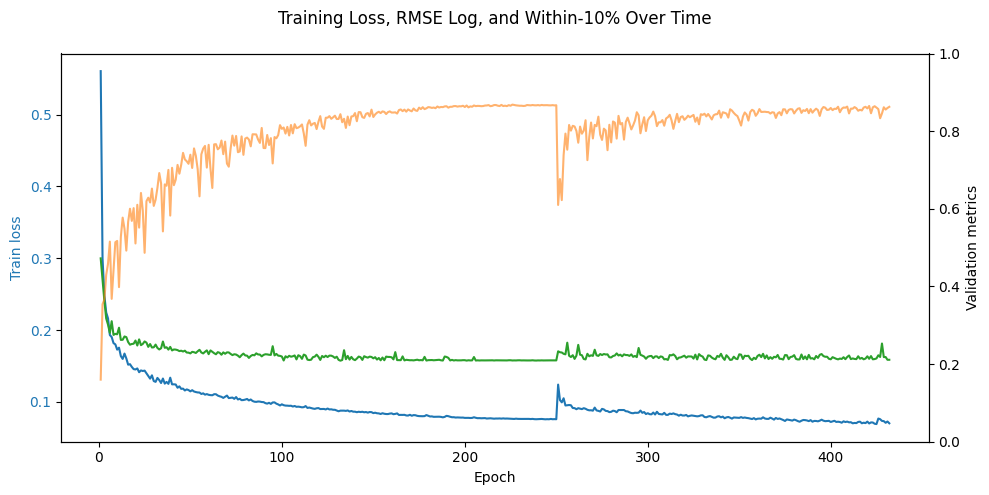

,epoch,train_loss,lr,rmse_log,rmse_ms,rmse_percent,median_relative_error,p90_relative_error,p95_relative_error,within_10pct,median_ratio_error,p90_ratio_error,within_25pct,within_50pct,within_2x
131,132,0.087734,0.000370,0.208695,159.586936,0.393726,0.033539,0.147684,0.289905,0.843662,1.034229,1.158604,0.940666,0.970528,0.983361
200,201,0.077676,0.000083,0.208980,157.137212,0.404280,0.023092,0.136990,0.297025,0.866010,1.023473,1.145962,0.941007,0.969406,0.983215
238,239,0.075775,0.000014,0.209076,158.757308,0.405571,0.022228,0.137263,0.293316,0.866449,1.022603,1.146750,0.941544,0.969698,0.983312
178,179,0.081588,0.000157,0.209111,155.612518,0.399137,0.028085,0.142023,0.297777,0.858788,1.028437,1.151223,0.941397,0.969064,0.983507
205,206,0.077777,0.000069,0.209125,157.764417,0.404018,0.026499,0.138613,0.288137,0.864448,1.026995,1.148360,0.942813,0.970235,0.983556
187,188,0.078421,0.000124,0.209160,159.652987,0.407777,0.025506,0.140208,0.293394,0.861862,1.025885,1.150731,0.942325,0.969503,0.983068
100,101,0.095335,0.000522,0.209234,156.035471,0.359310,0.042632,0.164302,0.305187,0.809310,1.044134,1.181485,0.938860,0.971504,0.984434
207,208,0.077332,0.000064,0.209241,159.981450,0.404534,0.024647,0.136053,0.293354,0.864887,1.025025,1.145326,0.941349,0.969308,0.983215
234,235,0.076234,0.000017,0.209250,160.894114,0.405633,0.022360,0.136249,0.297290,0.866888,1.022628,1.146295,0.941446,0.969406,0.983263
225,226,0.076433,0.000028,0.209268,160.936572,0.407912,0.021777,0.135691,0.299276,0.868352,1.022050,1.144893,0.941007,0.969162,0.983166


In [25]:
import pandas as pd
import matplotlib.pyplot as plt

history_df = pd.DataFrame(history)

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Train loss",
    color="tab:blue",
)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Train loss", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(
    history_df["epoch"],
    history_df["rmse_log"],
    label="Val RMSE log",
    color="tab:green",
)
ax2.plot(
    history_df["epoch"],
    history_df["within_10pct"],
    label="Within 10%",
    color="tab:orange",
    alpha=0.6,
)
ax2.set_ylabel("Validation metrics")
ax2.set_ylim(0, max(1.0, history_df["rmse_log"].max() * 1.1))

fig.suptitle("Training Loss, RMSE Log, and Within-10% Over Time")
fig.tight_layout()
plt.show()

history_df.sort_values(["rmse_log", "within_10pct"], ascending=[True, False]).head(10)

In [26]:
model.load_state_dict(best_state["model"])
print("Best epoch:", best_state["epoch"])
print("Best val RMSE:", best_state["val_rmse"])
print("Best val within_10pct:", best_state["val_within_10pct"])

Best epoch: 132
Best val RMSE: 0.20869480107089505
Best val within_10pct: 0.8436615594808237


In [27]:
val_metrics, val_true_log, val_pred_log = evaluate_mlp(model, val_loader)
test_metrics, test_true_log, test_pred_log = evaluate_mlp(model, test_loader)

pd.DataFrame([val_metrics, test_metrics], index=["val", "test"])

,rmse_log,rmse_ms,rmse_percent,median_relative_error,p90_relative_error,p95_relative_error,within_10pct,median_ratio_error,p90_ratio_error,within_25pct,within_50pct,within_2x
val,0.208695,159.586936,0.393726,0.033539,0.147684,0.289905,0.843662,1.034229,1.158604,0.940666,0.970528,0.983361
test,0.190830,130.568514,0.291452,0.032246,0.142126,0.290860,0.850546,1.032880,1.152949,0.943005,0.969797,0.984217


# Save Model

In [29]:
from pathlib import Path
import torch

model_dir = Path("/content/drive/MyDrive/Models")
model_dir.mkdir(parents=True, exist_ok=True)

save_path = model_dir / "11.pt"

if "best_state" in globals() and best_state is not None:
    model.load_state_dict(best_state["model"])

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "n_model_features": X_model_train.shape[1],
        "n_hw_features": X_hw_train.shape[1],
        "model_feature_cols": model_feature_cols,
        "hardware_feature_cols": hardware_feature_cols,
        "model_scaler": model_scaler,
        "hw_scaler": hw_scaler,
        "target_col": "log_average_ms",
        "best_val_rmse": best_val_rmse if "best_val_rmse" in globals() else None,
        "best_val_within_10pct": best_within_10 if "best_within_10" in globals() else None,
        "selection_metric": "rmse_log",
        "seed": SEED,
    },
    save_path,
)

print("Saved to:", save_path)

Saved to: /content/drive/MyDrive/Models/11.pt


# Analysis

In [ ]:
test_results = test_df.copy()

test_results["pred_log_latency"] = test_pred_log
test_results["true_log_latency"] = test_true_log

test_results["pred_latency_ms"] = np.exp(test_results["pred_log_latency"])
test_results["true_latency_ms"] = np.exp(test_results["true_log_latency"])

test_results["relative_error"] = (
    np.abs(test_results["pred_latency_ms"] - test_results["true_latency_ms"])
    / test_results["true_latency_ms"]
)

In [ ]:
def group_latency_metrics(g):
    y_true = g["true_log_latency"].to_numpy()
    y_pred = g["pred_log_latency"].to_numpy()

    true_ms = np.exp(y_true)
    pred_ms = np.exp(y_pred)

    rel_err = np.abs(pred_ms - true_ms) / true_ms

    return pd.Series({
        "count": len(g),
        "rmse_log": np.sqrt(mean_squared_error(y_true, y_pred)),
        "within_10pct": np.mean(rel_err <= 0.10),
        "within_25pct": np.mean(rel_err <= 0.25),
        "within_50pct": np.mean(rel_err <= 0.50),
    })

In [ ]:
test_results["abs_log_error"] = np.abs(
    test_results["pred_log_latency"] - test_results["true_log_latency"]
)

test_results.groupby(["cpu_provider", "platform", "num_cores"])["relative_error"].agg(
    count="count",
    median="median",
    p90=lambda x: x.quantile(0.9),
    within_10pct=lambda x: (x <= 0.10).mean(),
    within_25pct=lambda x: (x <= 0.25).mean(),
).reset_index()

In [ ]:
test_results.groupby(["cpu_provider", "platform", "num_cores"])["cv"].agg(
    within_10pct=lambda x: (x <= 0.10).mean(),
    count="count",
    median="median",
    p90=lambda x: x.quantile(0.9),
).reset_index()

In [ ]:
test_results.groupby(["cpu_provider", "platform", "num_cores"]).apply(
    group_latency_metrics,
    include_groups=False
).reset_index()